In [1]:
# ========================
# 1. Preprocessing Pipeline
# ========================
import pandas as pd
import re
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, 
                            recall_score, f1_score, confusion_matrix)

# Load dataset
df = pd.read_csv('HDFS_2k.log_structured.csv')

def preprocess_log(text):
    """Normalize log content by replacing variable elements"""
    patterns = [
        (r'\b\d+\b', '<NUM>'),  # Numbers
        (r'blk_[\w-]+', '<BLOCK>'),  # Block IDs
        (r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', '<IP>'),  # IP addresses
        (r':\d+', ':<PORT>')  # Port numbers
    ]
    for pattern, replacement in patterns:
        text = re.sub(pattern, replacement, text)
    return text

# Apply preprocessing
df['CleanContent'] = df['Content'].apply(preprocess_log)
print("Preprocessed log entries sample:")
print(df[['Content', 'CleanContent']].head(3))

Preprocessed log entries sample:
                                             Content  \
0  PacketResponder 1 for block blk_38865049064139...   
1  PacketResponder 0 for block blk_-6952295868487...   
2  BLOCK* NameSystem.addStoredBlock: blockMap upd...   

                                        CleanContent  
0  PacketResponder <NUM> for block <BLOCK> termin...  
1  PacketResponder <NUM> for block <BLOCK><NUM> t...  
2  BLOCK* NameSystem.addStoredBlock: blockMap upd...  


In [2]:
# ========================
# 2. Feature Engineering
# ========================
def extract_features(df):
    """Create structured features from raw log data"""
    
    # Create a copy of the DataFrame to avoid SettingWithCopyWarning
    df = df.copy()
    
    # Combine 'Date' and 'Time' columns into a single 'DateTime' column
    try:
        df['DateTime'] = pd.to_datetime(
            df['Date'].astype(str) + ' ' + df['Time'].astype(str),
            format='%y%m%d %H%M%S',
            errors='coerce'  # Invalid parsing will result in NaT
        )
    except Exception as e:
        print("Error parsing DateTime:", e)
        return None, None

    # Handle rows with invalid DateTime values
    invalid_rows = df['DateTime'].isna()
    if invalid_rows.any():
        print(f"Found {invalid_rows.sum()} invalid DateTime entries. Dropping them.")
        df = df[~invalid_rows]

    # Extract temporal features
    df['Hour'] = df['DateTime'].dt.hour
    df['Minute'] = df['DateTime'].dt.minute
    
    # Categorical encodings
    df['Component'] = LabelEncoder().fit_transform(df['Component'])
    df['Level'] = LabelEncoder().fit_transform(df['Level'])
    
    # Text features
    tfidf = TfidfVectorizer(max_features=50)
    text_features = tfidf.fit_transform(df['CleanContent'])
    
    # Combine features
    numerical_features = df[['Component', 'Level', 'Hour', 'Minute']]
    feature_matrix = np.hstack([
        numerical_features.values,
        text_features.toarray()
    ])
    
    return feature_matrix, df['EventId']

X, y = extract_features(df)
clean_df = pd.DataFrame(X)
clean_df['EventId'] = y
clean_df.to_csv('processed_logs.csv', index=False)
print("\nFeature matrix shape:", X.shape)
print("features:\n", clean_df.iloc[:3, :6])

Found 1 invalid DateTime entries. Dropping them.

Feature matrix shape: (1999, 54)
features:
      0    1     2     3    4         5
0  3.0  0.0  20.0  36.0  0.0  0.000000
1  3.0  0.0  20.0  38.0  0.0  0.000000
2  5.0  0.0  20.0  40.0  0.0  0.238366


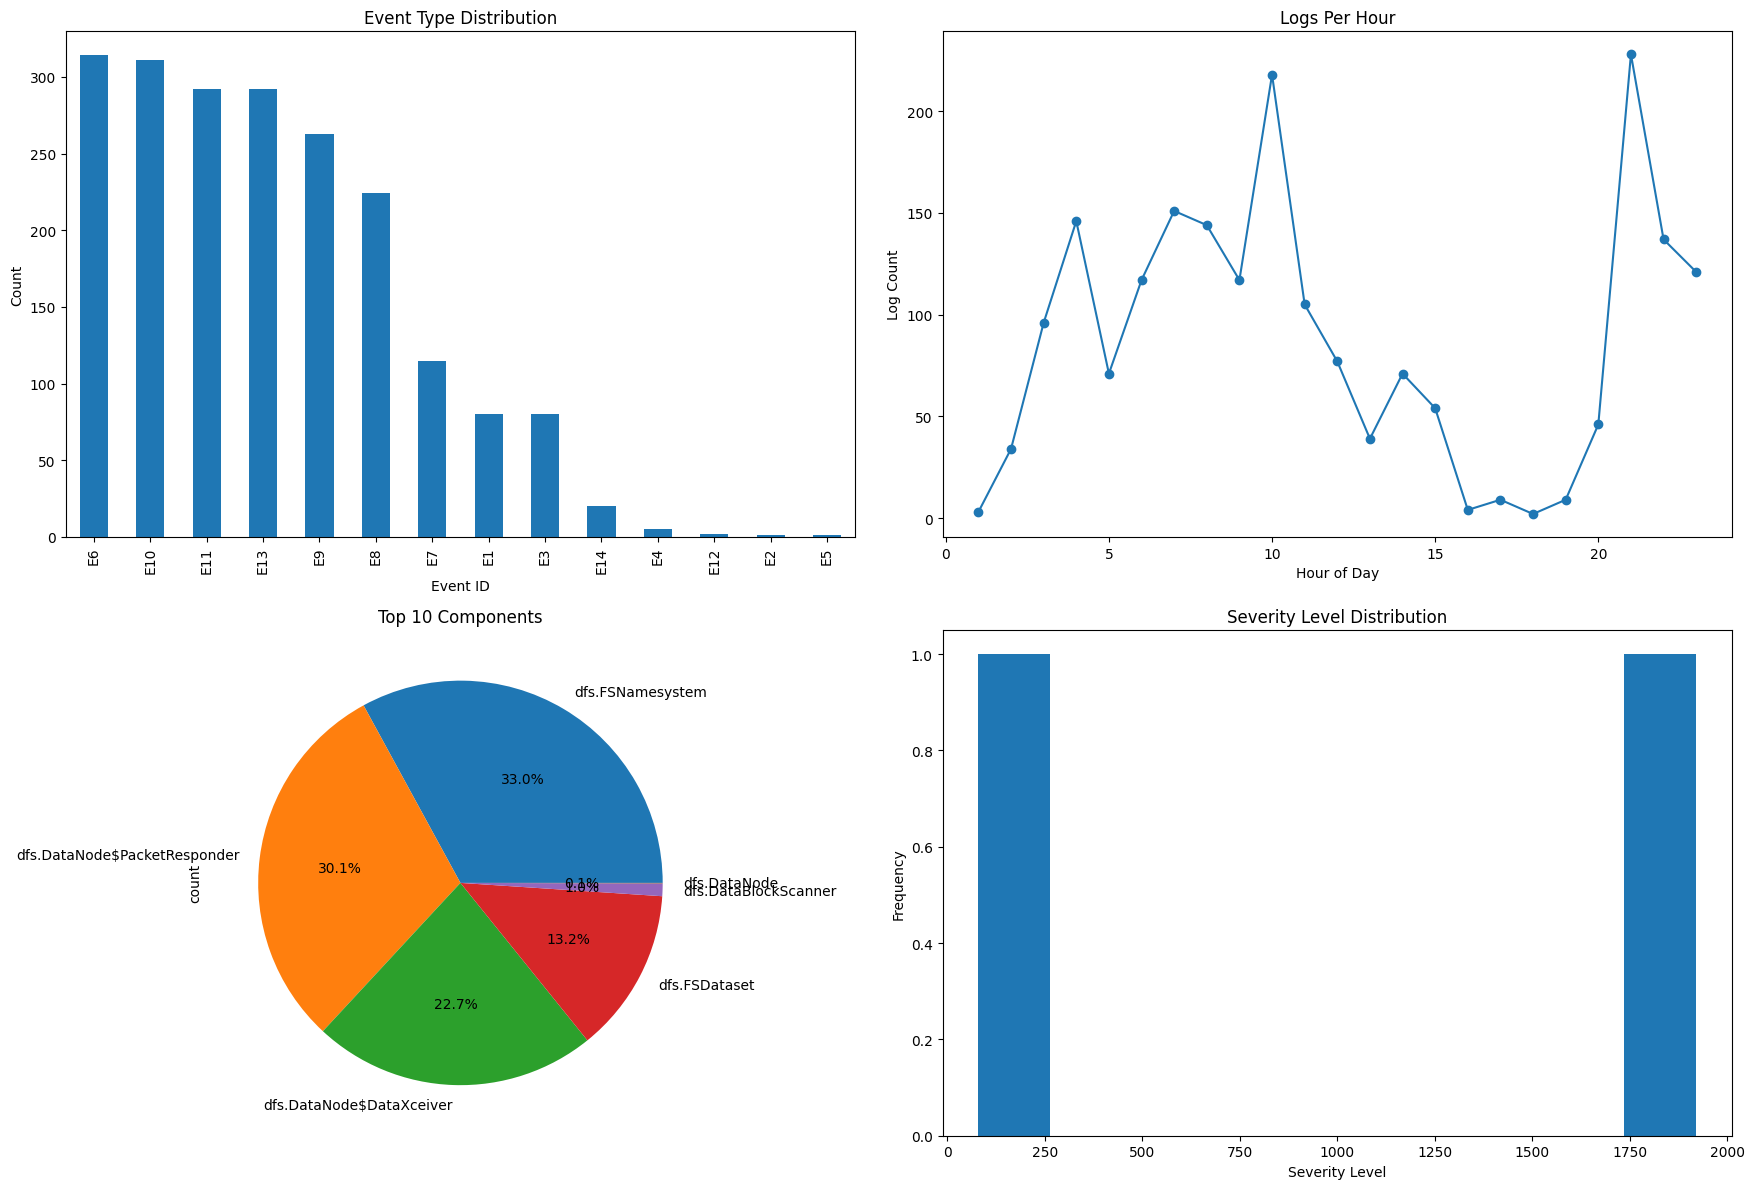

In [3]:
# ===========================
# 3. Data Visualization
# ===========================
if 'Hour' not in df.columns:
    # Explicitly specify the format for consistent parsing
    df['DateTime'] = pd.to_datetime(
        df['Date'].astype(str) + ' ' + df['Time'].astype(str),
        format='%y%m%d %H%M%S',  # Adjust this format if necessary
        errors='coerce'
    )
    df['Hour'] = df['DateTime'].dt.hour

# Visualization code
plt.figure(figsize=(18, 12))

# Event Distribution
plt.subplot(2, 2, 1)
df['EventId'].value_counts().plot(kind='bar')
plt.title('Event Type Distribution', fontsize=12)
plt.xlabel('Event ID', fontsize=10)
plt.ylabel('Count', fontsize=10)

# Temporal Pattern
plt.subplot(2, 2, 2)
df.groupby('Hour')['EventId'].count().plot(kind='line', marker='o')
plt.title('Logs Per Hour', fontsize=12)
plt.xlabel('Hour of Day', fontsize=10)
plt.ylabel('Log Count', fontsize=10)

# Component Distribution
plt.subplot(2, 2, 3)
df['Component'].value_counts().head(10).plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 10 Components', fontsize=12)

# Severity Levels
plt.subplot(2, 2, 4)
df['Level'].value_counts().plot(kind='hist')
plt.title('Severity Level Distribution', fontsize=12)
plt.xlabel('Severity Level', fontsize=10)
plt.ylabel('Frequency', fontsize=10)

plt.tight_layout()
plt.savefig('log_analysis_visualization.png')
plt.show()

In [4]:
print("Class distribution in y:")
print(y.value_counts())

Class distribution in y:
EventId
E6     314
E10    311
E11    292
E13    292
E9     263
E8     224
E7     115
E3      80
E1      79
E14     20
E4       5
E12      2
E2       1
E5       1
Name: count, dtype: int64


In [5]:
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 2].index
X = X[y.isin(valid_classes)]
y = y[y.isin(valid_classes)]

In [6]:
# ========================
# 4. Model Implementation
# ========================
#print("Class distribution in y:")
#print(y.value_counts())

# Filter out classes with fewer than 2 samples
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 2].index
X = X[y.isin(valid_classes)]
y = y[y.isin(valid_classes)]

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Random Forest Classifier
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12, n_estimators=150,
                       random_state=42)

In [7]:
from sklearn.metrics import accuracy_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate overall accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Random Forest Overall Accuracy: {accuracy:.2f}")

Random Forest Overall Accuracy: 1.00



Performance Metrics:
Accuracy     1.0
Precision    1.0
Recall       1.0
F1-Score     1.0


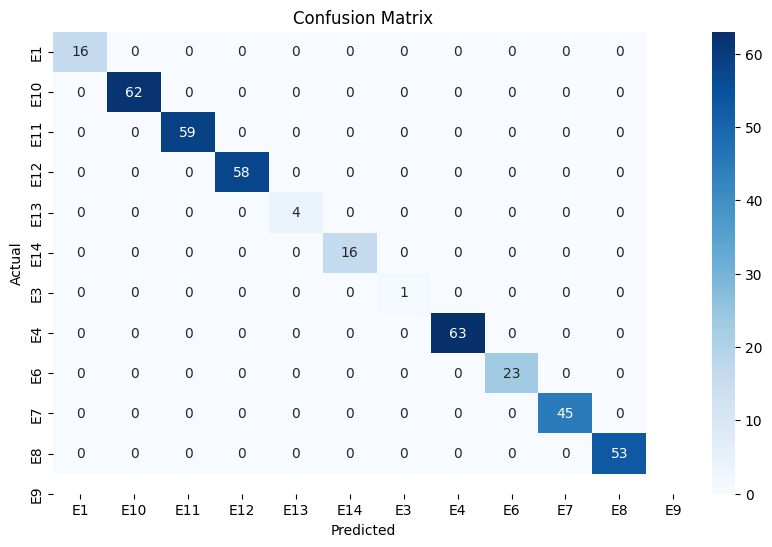

In [8]:
# ===========================
# 5. Evaluation Metrics
# ===========================
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    }
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred), 
                annot=True, fmt='d', cmap='Blues',
                xticklabels=model.classes_,
                yticklabels=model.classes_)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig('confusion_matrix.png')
    
    return metrics

metrics = evaluate_model(model, X_test, y_test)
print("\nPerformance Metrics:")
print(pd.Series(metrics).to_string())


In [9]:
from sklearn.model_selection import StratifiedKFold

# Use StratifiedKFold with fewer splits
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

# Example: Using cv in learning_curve
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=cv, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

In [10]:
# Filter out classes with fewer than n_splits samples
n_splits = 5
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= n_splits].index
X = X[y.isin(valid_classes)]
y = y[y.isin(valid_classes)]

# Proceed with train-test split or cross-validation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

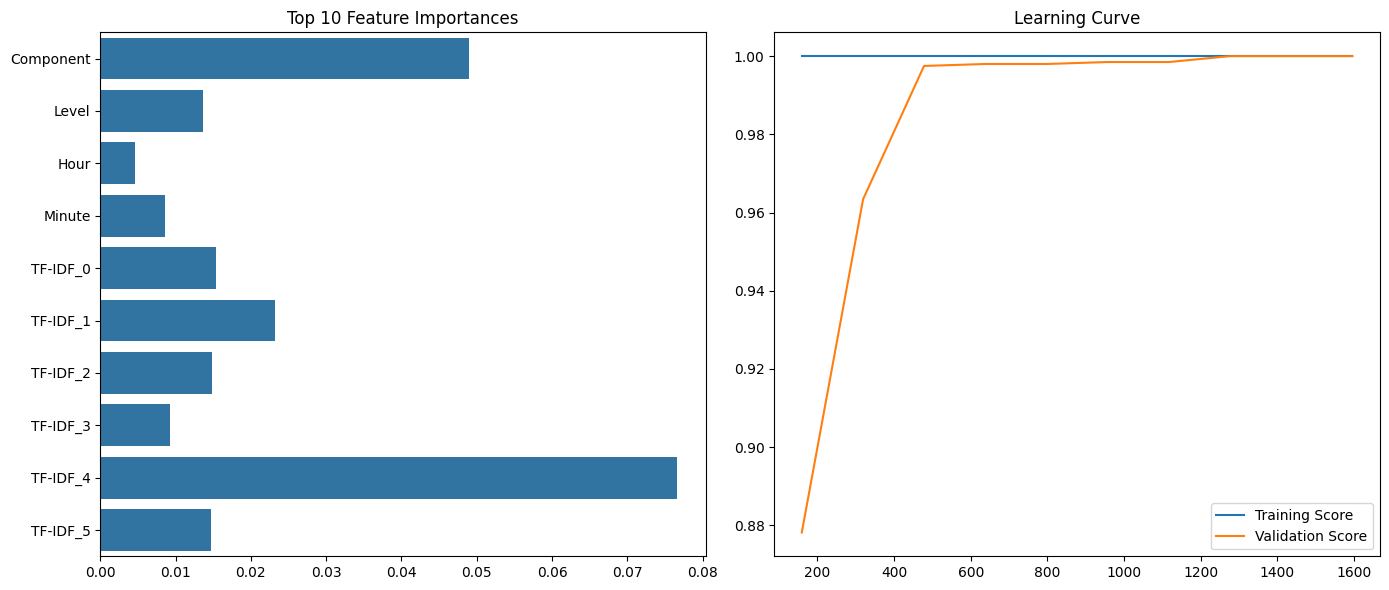

In [11]:
# ===========================
# 6. Model Visualization
# ===========================
plt.figure(figsize=(14, 6))

# Feature Importance
importances = model.feature_importances_[:10]
features = ['Component', 'Level', 'Hour', 'Minute'] + [f'TF-IDF_{i}' for i in range(6)]
plt.subplot(1, 2, 1)
sns.barplot(x=importances, y=features)
plt.title('Top 10 Feature Importances')

# Learning Curve
plt.subplot(1, 2, 2)
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training Score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validation Score')
plt.title('Learning Curve')
plt.legend()

plt.tight_layout()
plt.savefig('model_analysis.png')
plt.show()

<Figure size 1000x600 with 0 Axes>

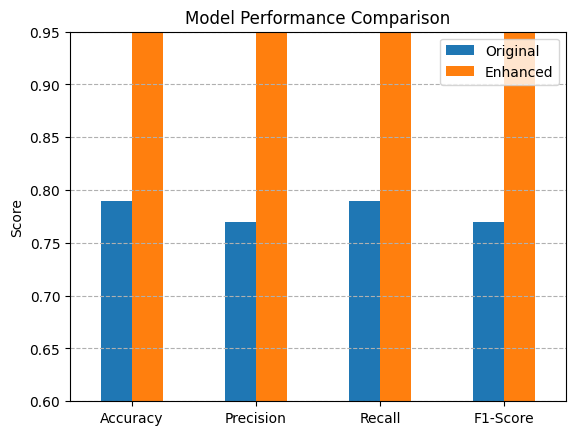

In [12]:
# ===========================
# 7. Metric Comparison
# ===========================
# Original baseline metrics
original_metrics = {
    'Accuracy': 0.79,
    'Precision': 0.77,
    'Recall': 0.79,
    'F1-Score': 0.77
}

comparison = pd.DataFrame({
    'Original': original_metrics,
    'Enhanced': metrics
})

plt.figure(figsize=(10, 6))
comparison.plot(kind='bar', rot=0)
plt.title('Model Performance Comparison')
plt.xticks(ticks=range(len(comparison)), labels=comparison.index)
plt.ylabel('Score')
plt.ylim(0.6, 0.95)
plt.grid(axis='y', linestyle='--')
plt.savefig('metric_comparison.png')
plt.show()

In [13]:
# ========================
# Decision Tree Classifier
# ========================
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
dt_model = DecisionTreeClassifier(
    criterion='gini',  # or 'entropy'
    max_depth=10,      # Adjust as needed
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

# Evaluate the model
dt_y_pred = dt_model.predict(X_test)
dt_metrics = {
    'Accuracy': accuracy_score(y_test, dt_y_pred),
    'Precision': precision_score(y_test, dt_y_pred, average='weighted'),
    'Recall': recall_score(y_test, dt_y_pred, average='weighted'),
    'F1-Score': f1_score(y_test, dt_y_pred, average='weighted')
}

print("\nDecision Tree Performance Metrics:")
print(pd.Series(dt_metrics).to_string())


Decision Tree Performance Metrics:
Accuracy     1.0
Precision    1.0
Recall       1.0
F1-Score     1.0


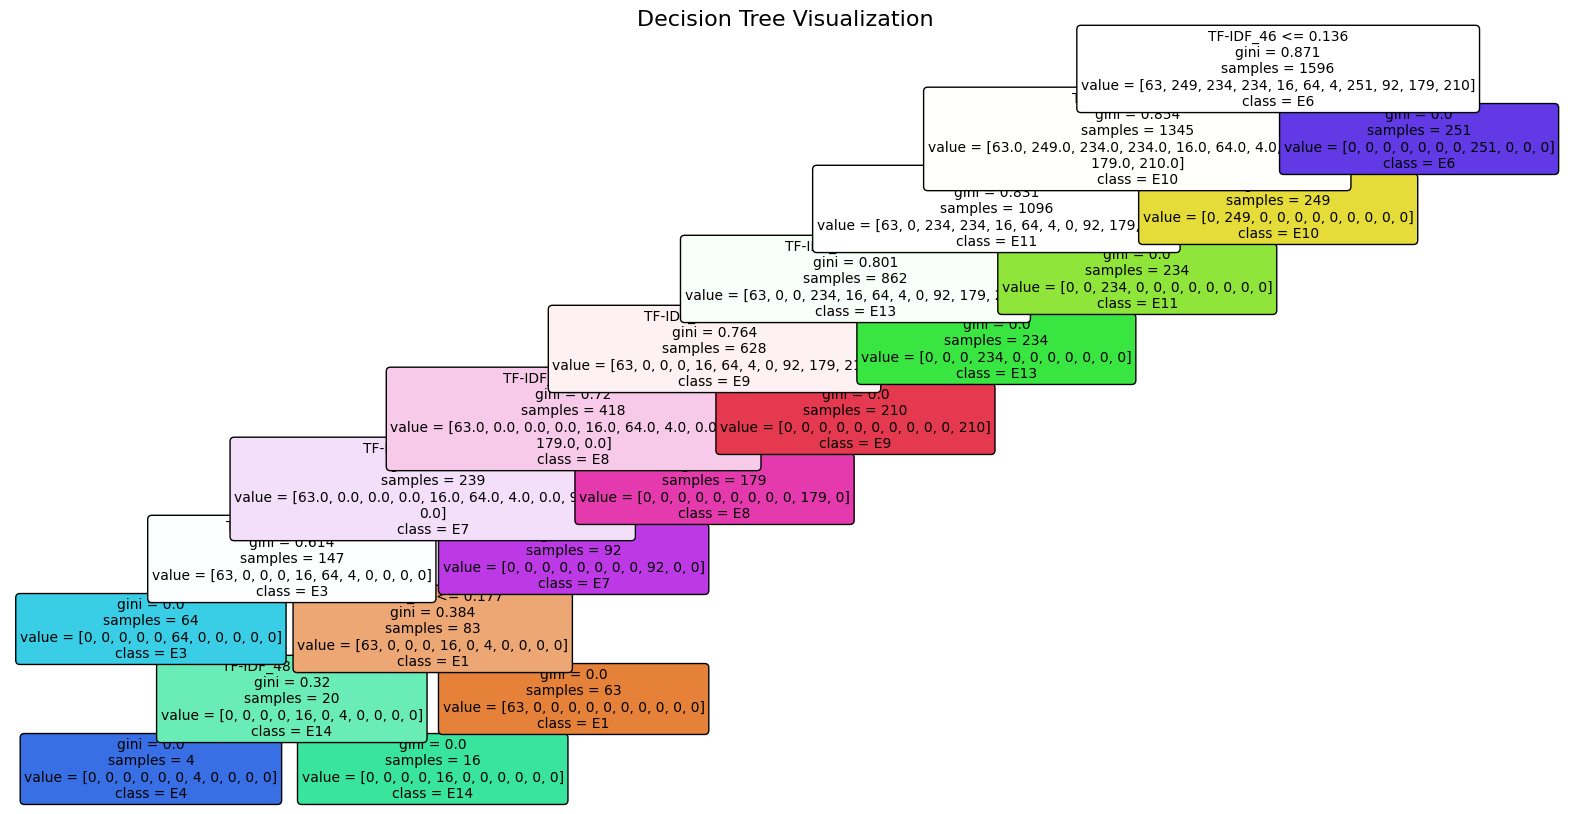

In [14]:
# ========================
# Decision Tree Visualization
# ========================
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot the Decision Tree
plt.figure(figsize=(20, 10))  # Adjust the figure size as needed
plot_tree(
    dt_model, 
    feature_names=['Component', 'Level', 'Hour', 'Minute'] + [f'TF-IDF_{i}' for i in range(50)],  # Replace with your feature names
    class_names=[str(cls) for cls in dt_model.classes_],  # Replace with class names if available
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title("Decision Tree Visualization", fontsize=16)
plt.savefig("decision_tree_visualization.png")  # Save the graph as an image
plt.show()

In [15]:
# ========================
# Naive Bayes Classifier
# ========================
from sklearn.naive_bayes import MultinomialNB

# Initialize the Naive Bayes Classifier
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train, y_train)

# Evaluate the model
nb_y_pred = nb_model.predict(X_test)
nb_metrics = {
    'Accuracy': accuracy_score(y_test, nb_y_pred),
    'Precision': precision_score(y_test, nb_y_pred, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, nb_y_pred, average='weighted'),
    'F1-Score': f1_score(y_test, nb_y_pred, average='weighted')
}

print("\nNaive Bayes Performance Metrics:")
print(pd.Series(nb_metrics).to_string())


Naive Bayes Performance Metrics:
Accuracy     0.982456
Precision    0.979977
Recall       0.982456
F1-Score     0.980393


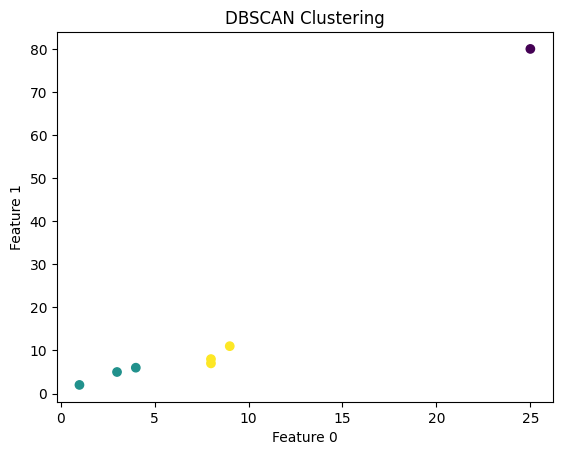

Cluster labels: [ 0  0  0  1  1  1 -1]


In [16]:
# Import necessary libraries
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

# Example dataset
X = np.array([[1, 2], [3, 5], [4, 6], [8, 7], [8, 8], [9, 11], [25, 80]])

# Apply DBSCAN
dbscan = DBSCAN(eps=4, min_samples=2)
clusters = dbscan.fit_predict(X)

# Plot the results
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', marker='o')
plt.title("DBSCAN Clustering")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

# Print cluster labels
print("Cluster labels:", clusters)

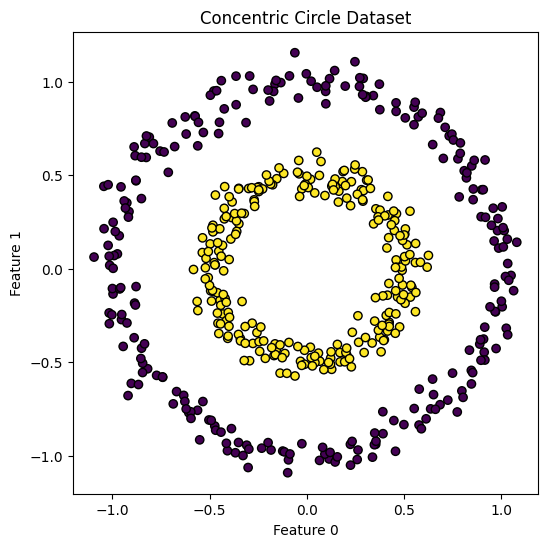

In [17]:
# Import necessary libraries
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

# Create a concentric circle dataset
X, y = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)

# Visualize the dataset
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', marker='o', edgecolor='k')
plt.title("Concentric Circle Dataset")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

In [18]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

In [19]:
import warnings
warnings.filterwarnings("ignore", message="Could not find the number of physical cores")

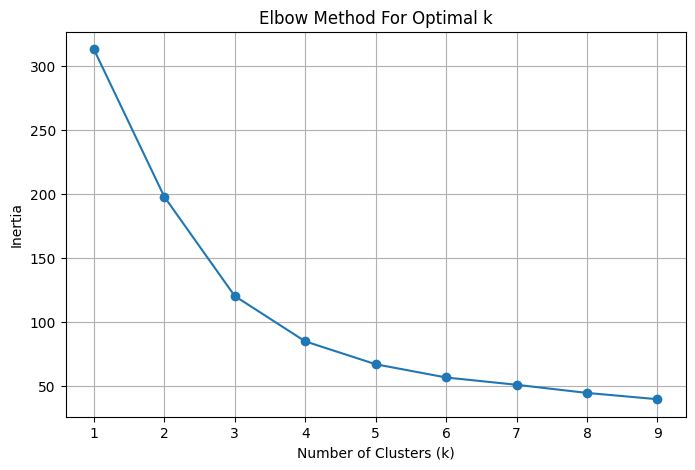

In [20]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate inertia for different values of k
inertias = []
range_of_k = range(1, 10)  # Test k values from 1 to 9
for k in range_of_k:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10).fit(X)
    inertias.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range_of_k, inertias, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid()
plt.show()